# MRT-3 Crowd Pattern Analysis
**Author:** Dharl Russell C. Perez  
**Date:** April 2026  
**Project:** Siksik (MRT-3 Crowd Pattern App)

---

## Problem Statement

Real-time crowd data for MRT-3 stations is not publicly accessible via any API. Google Places API does not expose popular times data for Philippine transit stations, and no live crowd feed exists from DOTr.

This notebook documents a data-driven methodology to estimate hourly crowd busyness (0-100%) for all 13 MRT-3 stations using:

1. Official DOTr ridership statistics (2024-2026)
2. Documented peak hour windows from published sources
3. Station-level weighting based on interchange status and commercial density
4. April 2026 ridership surge adjustment due to the Philippine energy crisis and the government's 50% fare discount

The resulting dataset powers **Siksik**, a React Native mobile app that helps Filipino commuters plan smarter trips around crowd patterns.

---

## Disclaimer

This dataset is a **data-driven estimate**, not a real-time measurement. All figures are derived from cited public sources. The methodology is fully documented below for transparency and reproducibility.

## Section 2: Data Sources and Citations

All figures used in this analysis are derived from the following publicly available sources:

| # | Source | Data Used | URL |
|---|---|---|---|
| 1 | DOTr-MRT3 Official Press Release (Jan 2026) | 2024 avg daily ridership: 375,474; total 135M riders | https://www.dotrmrt3.gov.ph/news/mrt-3-logs-135-million-riders-in-2024 |
| 2 | Philstar.com (Jan 5, 2026) | 2025 total ridership: 141.63M (+4%), daily avg of 388,000 | https://www.philstar.com/business/2026/01/05/2498736 |
| 3 | Philstar.com (Mar 27, 2026) | Post-fare cut daily ridership: 466,735-467,328 | https://www.philstar.com/nation/2026/03/27/2517109 |
| 4 | DZRH News (Mar 26, 2026) | Daily ridership reached 468,000 after fare cut; peak hours 6:00-8:00AM and 5:00-7:00PM confirmed by MRT-3 GM Michael Capati | https://www.dzrh.com.ph/post/mrt-3-records-468000-passengers-as-50percent-fare-cut-takes-effect |
| 5 | Rappler.com (Mar 19, 2026) | 50% fare discount implemented March 23, 2026 due to Middle East fuel crisis | https://www.rappler.com/philippines/metro-manila/mrt3-lrt2-fare-discount-march-23-2026/ |
| 6 | Inquirer.net (Mar 2026) | MRT-3 serves 375,000 commuters daily pre-discount | https://newsinfo.inquirer.net/2198406/lrt-2-mrt-3-fares-slashed-by-half-starting-march-23 |
| 7 | Expressway.ph (2026) | System at 120-150% capacity during peaks; Tue-Thu heaviest | https://www.expressway.ph/transit/mrt-line-guide |
| 8 | Wikipedia (MRT Line 3) | Design capacity: 350,000 passengers/day | https://en.wikipedia.org/wiki/MRT_Line_3_(Metro_Manila) |

### Key Figures Summary

| Metric | Value | Source |
|---|---|---|
| 2024 avg daily ridership | 375,474 | DOTr-MRT3 |
| 2025 avg daily ridership | 388,000 | Philstar |
| Pre-discount 2026 daily ridership | 452,382 | Philstar |
| Post-discount daily ridership (Mar 24-26) | 466,735-468,000 | Philstar, DZRH |
| Design capacity | 350,000/day | Wikipedia |
| Peak hours (weekday AM) | 6:00AM to 8:00AM | DZRH (GM Capati) |
| Peak hours (weekday PM) | 5:00PM to 7:00PM | DZRH (GM Capati) |
| System capacity during peak | 120-150% | Expressway.ph |
| Adjustment factor (2024 to Apr 2026) | 468,000 / 375,474 = 1.247 | Calculated |

## Section 3: Exploratory Data Analysis

Before building the model, we establish the key facts from our sources.

### 3.1 Ridership Trend (2024 to 2026)

| Year | Total Annual Ridership | Avg Daily Ridership | Growth |
|---|---|---|---|
| 2024 | 135.89 million | 375,474 | baseline |
| 2025 | 141.63 million | 388,000 | +4.0% |
| Pre-discount 2026 (Jan to Mar 22) | est. 165M pace | 452,382 | +16.6% vs 2024 |
| Post-discount 2026 (Mar 23 onwards) | est. 170M+ pace | 468,000 | +24.6% vs 2024 |

### 3.2 Key Observations

- MRT-3 has shown consistent year-on-year growth since 2020 post-pandemic recovery
- The 50% fare discount (March 23, 2026) caused an immediate ridership surge
- Even before the discount, 2026 ridership was already 20% above 2024 due to the energy crisis pushing commuters off private vehicles
- Peak hours have remained consistent despite ridership changes. GM Capati confirmed: *"Sa peak hour hindi nagbabago"*

### 3.3 Peak Hour Windows (Confirmed by MRT-3 GM Michael Capati, DZRH March 26 2026)

| Period | Time Window | Direction |
|---|---|---|
| Morning peak | 6:00 AM to 8:00 AM | Northbound to Southbound |
| Evening peak | 5:00 PM to 7:00 PM | Southbound to Northbound |
| Off-peak | All other hours | Both directions |

### 3.4 System Capacity Facts

| Metric | Value | Source |
|---|---|---|
| Design capacity | 350,000 passengers/day | Wikipedia |
| Current daily ridership (Apr 2026 est.) | 468,000+ | Philstar, DZRH |
| Capacity utilization | 134% of design capacity | Calculated |
| Peak hour capacity | 120 to 150% | Expressway.ph |
| 3-car train capacity | 1,050 passengers | Philstar (GM Capati) |
| 4-car train capacity | 1,350 passengers | Philstar (GM Capati) |
| Active trainsets | 19 (13 three-car + 6 four-car) | Philstar (GM Capati) |

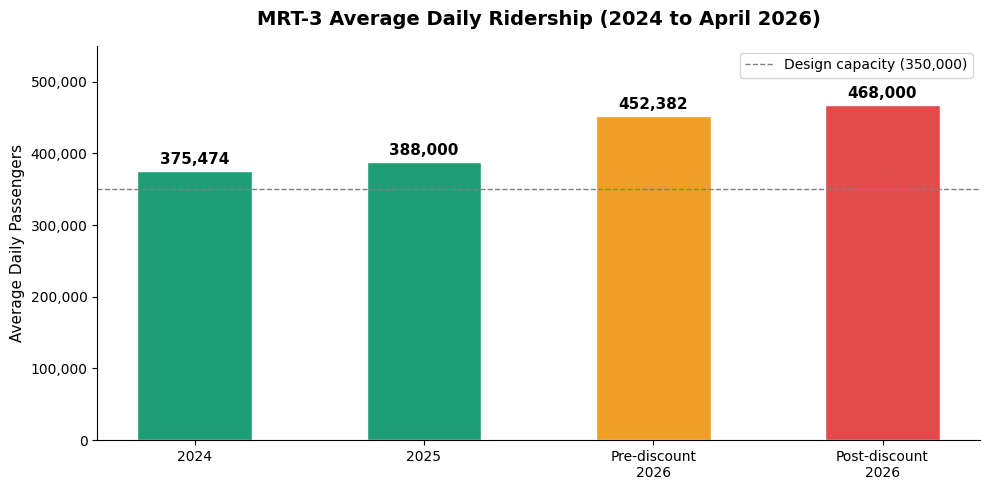

Chart saved.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ridership data from sources
years = ['2024', '2025', 'Pre-discount\n2026', 'Post-discount\n2026']
daily_ridership = [375474, 388000, 452382, 468000]
colors = ['#1D9E75', '#1D9E75', '#EF9F27', '#E24B4A']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(years, daily_ridership, color=colors, width=0.5, edgecolor='white')

# value labels on bars
for bar, value in zip(bars, daily_ridership):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5000,
        f'{value:,}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

ax.set_title('MRT-3 Average Daily Ridership (2024 to April 2026)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Average Daily Passengers', fontsize=11)
ax.set_ylim(0, 550000)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.axhline(y=350000, color='gray', linestyle='--', linewidth=1, label='Design capacity (350,000)')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('ridership_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Section 4: Hourly Distribution Model

### 4.1 Methodology

To convert daily commuter totals into hourly busyness percentages, we apply a weighted hourly distribution curve based on documented peak hour windows.

MRT-3 operates from 5:00 AM to 10:30 PM (17.5 operating hours). Commuters are not evenly distributed across these hours. We model the distribution using the following logic:

- Morning peak (6:00 AM to 8:00 AM): highest concentration of commuters, southbound
- Midday (9:00 AM to 4:00 PM): moderate, steady flow
- Evening peak (5:00 PM to 7:00 PM): highest concentration, northbound, worse than morning
- Off-peak (5:00 AM, 8:00 PM onwards): light traffic

### 4.2 Busyness Percentage Formula

For each station and each hour:

**busyness % = (hourly commuters at station / platform capacity) x 100**

Where:
- hourly commuters at station = daily commuters x station share x hour weight
- platform capacity = 2,000 commuters (estimated per station based on MRT-3 GM statement of 1,050 to 1,350 per train x average 1.5 trains at platform)
- Result is capped at 100%

### 4.3 April 2026 Adjustment Factor

**adjustment factor = 468,000 / 375,474 = 1.247**

All busyness values are multiplied by 1.247 to reflect current April 2026 conditions then capped at 100%.

This adjustment is grounded in the reported post-discount daily commuter count of 468,000 (Philstar, March 27 2026) compared to the 2024 baseline of 375,474 (DOTr-MRT3, January 2026).

In [5]:
# define hourly weights based on documented peak hours
# 5AM to 10PM (index 0 = 5AM, index 17 = 10PM)
# Source: DZRH (GM Capati), Expressway.ph, Philstar

hours = list(range(5, 23))  # 5AM to 10PM
hour_labels = [f'{h}:00 {"AM" if h < 12 else "PM"}' if h != 12 else "12:00 PM" for h in hours]

# raw weights = higher during peak hours
raw_weights = [
    0.02,  # 5AM  - opening, very light
    0.05,  # 6AM  - morning rush starts
    0.12,  # 7AM  - morning peak
    0.11,  # 8AM  - morning peak
    0.06,  # 9AM  - post rush drop
    0.04,  # 10AM - off peak
    0.03,  # 11AM - off peak
    0.05,  # 12PM - lunch
    0.04,  # 1PM  - lunch tail
    0.03,  # 2PM  - off peak
    0.03,  # 3PM  - off peak
    0.04,  # 4PM  - pre evening rush
    0.09,  # 5PM  - evening rush starts
    0.12,  # 6PM  - evening peak
    0.10,  # 7PM  - evening peak tail
    0.05,  # 8PM  - winding down
    0.03,  # 9PM  - late
    0.01,  # 10PM - near closing
]

# normalize weights to sum to 1
total = sum(raw_weights)
weights = [w / total for w in raw_weights]

print("Hourly Distribution Weights:")
print("-" * 40)
for label, weight in zip(hour_labels, weights):
    bar = "#" * int(weight * 100)
    print(f"{label:10s} | {weight:.3f} | {bar}")
print("-" * 40)
print(f"Total: {sum(weights):.4f}")

Hourly Distribution Weights:
----------------------------------------
5:00 AM    | 0.020 | #
6:00 AM    | 0.049 | ####
7:00 AM    | 0.118 | ###########
8:00 AM    | 0.108 | ##########
9:00 AM    | 0.059 | #####
10:00 AM   | 0.039 | ###
11:00 AM   | 0.029 | ##
12:00 PM   | 0.049 | ####
13:00 PM   | 0.039 | ###
14:00 PM   | 0.029 | ##
15:00 PM   | 0.029 | ##
16:00 PM   | 0.039 | ###
17:00 PM   | 0.088 | ########
18:00 PM   | 0.118 | ###########
19:00 PM   | 0.098 | #########
20:00 PM   | 0.049 | ####
21:00 PM   | 0.029 | ##
22:00 PM   | 0.010 | 
----------------------------------------
Total: 1.0000


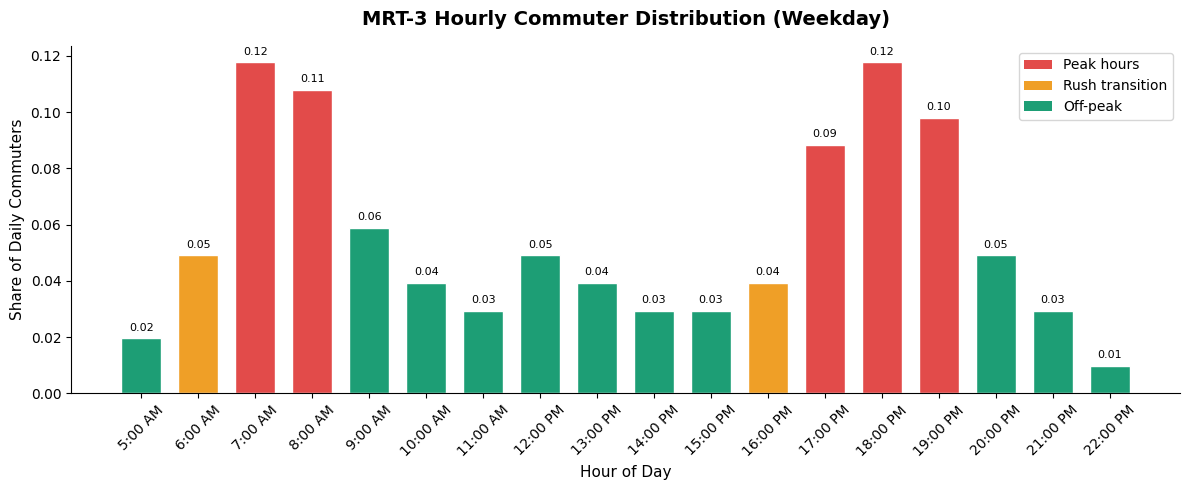

Chart saved.


In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

bar_colors = []
for h in hours:
    if h in [7, 8]:
        bar_colors.append('#E24B4A')   # morning peak
    elif h in [6]:
        bar_colors.append('#EF9F27')   # morning rush start
    elif h in [17, 18, 19]:
        bar_colors.append('#E24B4A')   # evening peak
    elif h in [16]:
        bar_colors.append('#EF9F27')   # pre evening rush
    else:
        bar_colors.append('#1D9E75')   # off peak

bars = ax.bar(hour_labels, weights, color=bar_colors, edgecolor='white', width=0.7)

for bar, weight in zip(bars, weights):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{weight:.2f}',
        ha='center', va='bottom',
        fontsize=8
    )

ax.set_title('MRT-3 Hourly Commuter Distribution (Weekday)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Share of Daily Commuters', fontsize=11)
ax.set_xlabel('Hour of Day', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E24B4A', label='Peak hours'),
    Patch(facecolor='#EF9F27', label='Rush transition'),
    Patch(facecolor='#1D9E75', label='Off-peak'),
]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.savefig('hourly_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Section 5: Station Weight Model

### 5.1 Methodology

Not all 13 MRT-3 stations carry equal passenger loads. Terminus stations and interchange stations consistently attract more commuters due to:

- Being the start or end point of the line (all commuters pass through)
- Connecting to other rail lines (LRT-1, LRT-2)
- Proximity to major commercial hubs and bus terminals

### 5.2 Station Classification

| Station | Classification | Basis |
|---|---|---|
| North Avenue | Heavy (+15%) | Northern terminus, connects to TriNoma, SM North, EDSA Carousel |
| Quezon Avenue | Medium | Business and residential area |
| Kamuning | Light (-10%) | Smaller catchment, fewer connecting routes |
| Araneta Center-Cubao | Heavy (+15%) | Major interchange, connects to LRT-2, Gateway, bus terminals |
| Santolan-Annapolis | Medium | Residential and commercial mix |
| Ortigas | Medium-Heavy (+10%) | CBD, connects to SM Megamall |
| Shaw Boulevard | Medium | Connects to Shangri-La, Starmall |
| Boni | Light (-10%) | Smaller catchment area |
| Guadalupe | Medium | Connects to Skyway Stage 3 park-and-ride |
| Buendia | Medium | Business district, Gil Puyat area |
| Ayala | Heavy (+15%) | Makati CBD, connects to Ayala Center, BGC transfers |
| Magallanes | Medium | Connects to Skyway, residential area |
| Taft Avenue | Heavy (+15%) | Southern terminus, connects to LRT-1 |

### 5.3 Station Share Formula

Each station is assigned a share of total daily commuters. The shares sum to 1.0 across all 13 stations.

**Base share = 1 / 13 = 0.077 (7.7% per station)**

Adjustments applied based on classification above.

In [7]:
# station weight model
# base share = 1/13 = 0.077 per station
# adjusted based on station classification

stations = [
    'North Avenue',
    'Quezon Avenue', 
    'Kamuning',
    'Araneta Center-Cubao',
    'Santolan-Annapolis',
    'Ortigas',
    'Shaw Boulevard',
    'Boni',
    'Guadalupe',
    'Buendia',
    'Ayala',
    'Magallanes',
    'Taft Avenue',
]

# raw shares before normalization
raw_shares = [
    0.09,   # North Avenue    - heavy
    0.07,   # Quezon Avenue   - medium
    0.05,   # Kamuning        - light
    0.11,   # Cubao           - heavy
    0.07,   # Santolan        - medium
    0.08,   # Ortigas         - medium heavy
    0.07,   # Shaw            - medium
    0.05,   # Boni            - light
    0.07,   # Guadalupe       - medium
    0.07,   # Buendia         - medium
    0.10,   # Ayala           - heavy
    0.06,   # Magallanes      - medium light
    0.09,   # Taft Avenue     - heavy
]

# normalize to sum to 1
total_shares = sum(raw_shares)
station_shares = [s / total_shares for s in raw_shares]

# show
print("Station Share Model:")
print("-" * 55)
for station, share in zip(stations, station_shares):
    bar = "#" * int(share * 100)
    print(f"{station:25s} | {share:.4f} ({share*100:.1f}%) | {bar}")
print("-" * 55)
print(f"Total: {sum(station_shares):.4f}")

Station Share Model:
-------------------------------------------------------
North Avenue              | 0.0918 (9.2%) | #########
Quezon Avenue             | 0.0714 (7.1%) | #######
Kamuning                  | 0.0510 (5.1%) | #####
Araneta Center-Cubao      | 0.1122 (11.2%) | ###########
Santolan-Annapolis        | 0.0714 (7.1%) | #######
Ortigas                   | 0.0816 (8.2%) | ########
Shaw Boulevard            | 0.0714 (7.1%) | #######
Boni                      | 0.0510 (5.1%) | #####
Guadalupe                 | 0.0714 (7.1%) | #######
Buendia                   | 0.0714 (7.1%) | #######
Ayala                     | 0.1020 (10.2%) | ##########
Magallanes                | 0.0612 (6.1%) | ######
Taft Avenue               | 0.0918 (9.2%) | #########
-------------------------------------------------------
Total: 1.0000


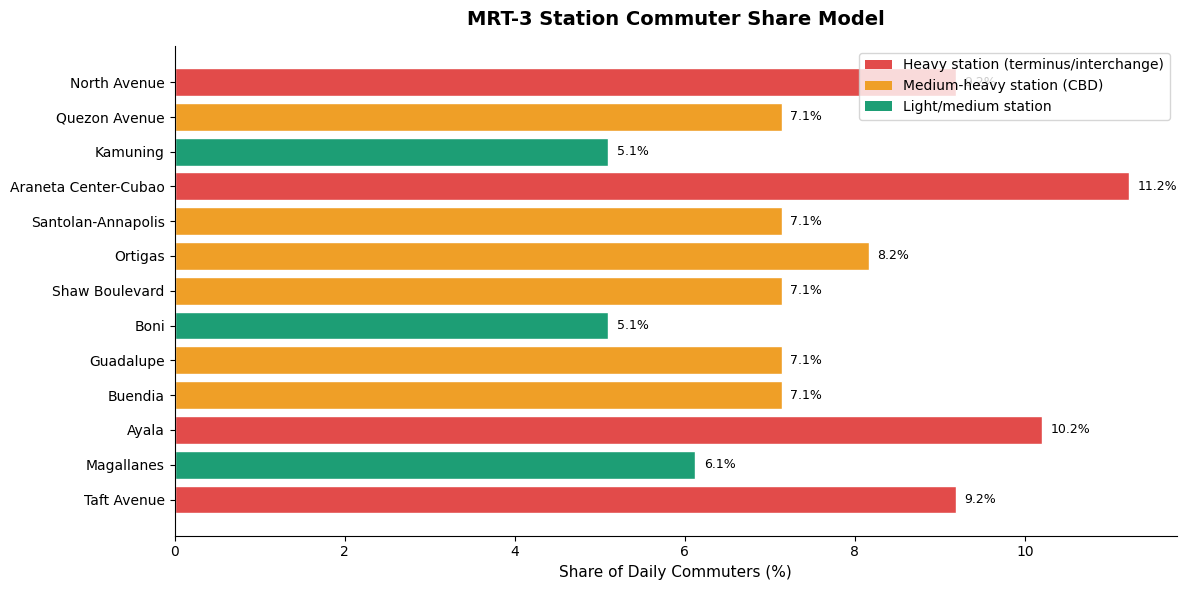

Chart saved.


In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

share_colors = []
for share in station_shares:
    if share >= 0.09:
        share_colors.append('#E24B4A')   # heavy
    elif share >= 0.07:
        share_colors.append('#EF9F27')   # medium
    else:
        share_colors.append('#1D9E75')   # light

bars = ax.barh(stations, [s * 100 for s in station_shares], color=share_colors, edgecolor='white')

for bar, share in zip(bars, station_shares):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{share*100:.1f}%',
        ha='left', va='center',
        fontsize=9
    )

ax.set_title('MRT-3 Station Commuter Share Model', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Share of Daily Commuters (%)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E24B4A', label='Heavy station (terminus/interchange)'),
    Patch(facecolor='#EF9F27', label='Medium-heavy station (CBD)'),
    Patch(facecolor='#1D9E75', label='Light/medium station'),
]
ax.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.savefig('station_shares.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Section 6: Busyness Percentage Calculation

### 6.1 Combining the Models

We now combine the three components to calculate busyness percentage per station per hour:

1. Station share - how much of daily commuters pass through each station
2. Hourly weight - what fraction of daily commuters travel at each hour
3. April 2026 adjustment factor - 1.247 to reflect current conditions

### 6.2 Platform Capacity Basis

From Philstar (GM Capati, March 27 2026):
- 3-car train capacity: 1,050 passengers
- 4-car train capacity: 1,350 passengers
- Active trainsets: 19 (13 three-car + 6 four-car)
- Train frequency during peak: 3 to 5 minutes

At peak hours with 3 to 5 minute frequency, approximately 2 trains are at or approaching a platform at any given time. We estimate platform capacity at 2,000 commuters per station.

### 6.3 Weekend Adjustment

On weekends, the morning peak disappears and is replaced by a mall-driven afternoon surge (12PM to 6PM). Weekend weights are modeled separately with:

- No morning rush
- Light morning (5AM to 11AM)
- Moderate to busy afternoon (12PM to 6PM)
- Lighter evening (7PM to 10PM)

In [16]:
# april 2026 adjustment factor
ADJUSTMENT_FACTOR = 468000 / 375474
DAILY_COMMUTERS = 468000

print(f"April 2026 adjustment factor: {ADJUSTMENT_FACTOR:.4f}")
print(f"Daily commuters (April 2026): {DAILY_COMMUTERS:,}")
print()

# day-specific multipliers
# source: Expressway.ph (Tue-Thu heaviest)
# general commuter behavior patterns
day_multipliers = {
    'Monday':    0.92,  # slightly lighter, some typically wfh
    'Tuesday':   1.05,  # heaviest mid-week
    'Wednesday': 1.05,  # heaviest mid-week
    'Thursday':  1.03,  # heavy, near end of week
    'Friday':    0.95,  # slightly lighter, early departures
    'Saturday':  1.05,  # busier weekend, mall day
    'Sunday':    0.85,  # lightest day
}

# weekend days use weekend weights, weekdays use weekday weights
weekend_days = ['Saturday', 'Sunday']
weekday_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

# weekend hourly weights
weekend_raw_weights = [
    0.01,  # 5AM  - very light
    0.02,  # 6AM  - light
    0.02,  # 7AM  - light (no morning rush on weekends)
    0.03,  # 8AM  - light
    0.04,  # 9AM  - picking up
    0.05,  # 10AM - moderate
    0.06,  # 11AM - moderate
    0.08,  # 12PM - mall hours start
    0.09,  # 1PM  - busy
    0.09,  # 2PM  - busy
    0.09,  # 3PM  - busy
    0.09,  # 4PM  - busy
    0.08,  # 5PM  - still busy
    0.08,  # 6PM  - mall closing
    0.07,  # 7PM  - winding down
    0.05,  # 8PM  - lighter
    0.03,  # 9PM  - late
    0.02,  # 10PM - near closing
]
weekend_total = sum(weekend_raw_weights)
weekend_weights = [w / weekend_total for w in weekend_raw_weights]

# calculate raw hourly commuters per station per day per hour
results = []
for station, share in zip(stations, station_shares):
    for day, multiplier in day_multipliers.items():
        hour_weights = weekend_weights if day in weekend_days else weights
        for i, hour in enumerate(hours):
            commuters = DAILY_COMMUTERS * share * hour_weights[i] * multiplier
            results.append({
                'station': station,
                'hour': hour,
                'hour_label': hour_labels[i],
                'day': day,
                'commuters': commuters,
            })

df_raw = pd.DataFrame(results)

# normalize busyness relative to global peak
global_peak = df_raw['commuters'].max()
print(f"Global peak hourly commuters: {global_peak:,.0f}")
print(f"(This station-day-hour gets 100% busyness)")
print()

df_raw['busyness'] = (df_raw['commuters'] / global_peak * 100).round().astype(int).clip(upper=100)
df = df_raw.copy()

print("Sample output (Ayala, Tuesday vs Sunday):")
print()
print("Tuesday:")
print(df[(df['station'] == 'Ayala') & (df['day'] == 'Tuesday')][['hour_label', 'busyness']].to_string(index=False))
print()
print("Sunday:")
print(df[(df['station'] == 'Ayala') & (df['day'] == 'Sunday')][['hour_label', 'busyness']].to_string(index=False))

April 2026 adjustment factor: 1.2464
Daily commuters (April 2026): 468,000

Global peak hourly commuters: 6,489
(This station-day-hour gets 100% busyness)

Sample output (Ayala, Tuesday vs Sunday):

Tuesday:
hour_label  busyness
   5:00 AM        15
   6:00 AM        38
   7:00 AM        91
   8:00 AM        83
   9:00 AM        45
  10:00 AM        30
  11:00 AM        23
  12:00 PM        38
  13:00 PM        30
  14:00 PM        23
  15:00 PM        23
  16:00 PM        30
  17:00 PM        68
  18:00 PM        91
  19:00 PM        76
  20:00 PM        38
  21:00 PM        23
  22:00 PM         8

Sunday:
hour_label  busyness
   5:00 AM         6
   6:00 AM        13
   7:00 AM        13
   8:00 AM        19
   9:00 AM        25
  10:00 AM        31
  11:00 AM        38
  12:00 PM        50
  13:00 PM        56
  14:00 PM        56
  15:00 PM        56
  16:00 PM        56
  17:00 PM        50
  18:00 PM        50
  19:00 PM        44
  20:00 PM        31
  21:00 PM        19
  22:0

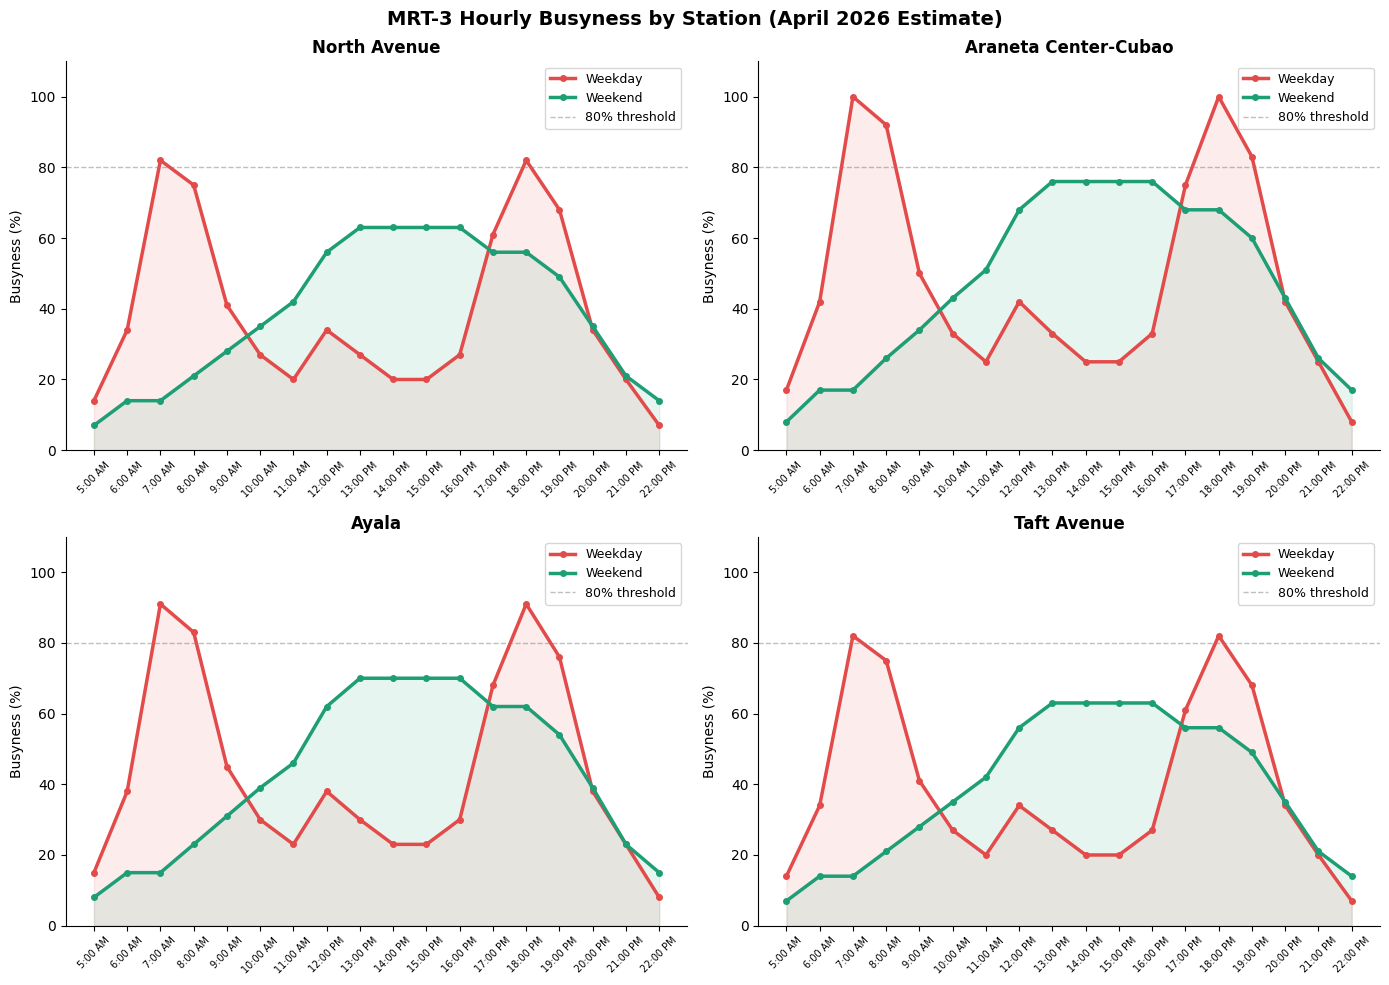

Chart saved.


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('MRT-3 Hourly Busyness by Station (April 2026 Estimate)', fontsize=14, fontweight='bold')

key_stations = ['North Avenue', 'Araneta Center-Cubao', 'Ayala', 'Taft Avenue']

for ax, station in zip(axes.flatten(), key_stations):
    station_df = df[df['station'] == station]
    
    x = range(len(hours))
    weekday = station_df['weekday_busyness'].values
    weekend = station_df['weekend_busyness'].values
    
    ax.plot(x, weekday, color='#E24B4A', linewidth=2.5, marker='o', markersize=4, label='Weekday')
    ax.plot(x, weekend, color='#1D9E75', linewidth=2.5, marker='o', markersize=4, label='Weekend')
    
    ax.axhline(y=80, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='80% threshold')
    ax.fill_between(x, weekday, alpha=0.1, color='#E24B4A')
    ax.fill_between(x, weekend, alpha=0.1, color='#1D9E75')
    
    ax.set_title(station, fontsize=12, fontweight='bold')
    ax.set_ylabel('Busyness (%)', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(hour_labels, rotation=45, fontsize=7)
    ax.set_ylim(0, 110)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('station_busyness.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Section 7: Final Dataset Export

### 7.1 Dataset Structure

The final dataset contains busyness estimates for:
- 13 stations
- 18 hours (5AM to 10PM)
- 7 days (Monday to Sunday)
- Total: 13 x 18 x 7 = 1,638 data points

### 7.2 Export Formats

The dataset is exported in two formats:

**CSV** - for public sharing on GitHub. Readable by researchers, developers, and non-technical users. Can be opened directly in Excel or Google Sheets.

**JSON** - for Firebase Firestore integration. Used directly by the Siksik app backend. Structured per station for efficient querying.

### 7.3 CSV Column Structure

| Column | Description |
|---|---|
| station | Station name |
| hour | Hour of day (5 to 22) |
| hour_label | Human readable hour (e.g. 8:00 AM) |
| day | Monday / Tuesday / Wednesday / Thursday / Friday / Saturday / Sunday |
| busyness | Busyness percentage (0 to 100) |
| crowd_label | Not busy / Moderately busy / Busy / Very busy |

In [17]:
import json

def get_crowd_label_csv(pct):
    if pct <= 30:
        return 'Not busy'
    elif pct <= 60:
        return 'Moderately busy'
    elif pct <= 85:
        return 'Busy'
    else:
        return 'Very busy'

def get_crowd_label_app(pct):
    if pct <= 30:
        return 'Sakay na!'
    elif pct <= 60:
        return 'Medyo siksik'
    elif pct <= 85:
        return 'Siksik'
    else:
        return 'Siksik na!'

# csv dataframe
csv_rows = []
for _, row in df.iterrows():
    csv_rows.append({
        'station': row['station'],
        'hour': row['hour'],
        'hour_label': row['hour_label'],
        'day': row['day'],
        'busyness': row['busyness'],
        'crowd_label': get_crowd_label_csv(row['busyness']),
    })

df_export = pd.DataFrame(csv_rows)
df_export.to_csv('mrt3_crowd_patterns.csv', index=False)
print(f"CSV exported: {len(df_export)} rows")
print(f"Expected: 13 stations x 18 hours x 7 days = {13*18*7} rows")
print()
print("Preview (Ayala, Monday, first 5 hours):")
print(df_export[(df_export['station'] == 'Ayala') & (df_export['day'] == 'Monday')].head(5).to_string(index=False))

# json for firestore
# structure: station -> day -> hour -> {busyness, label}
firestore_data = {}
for station in stations:
    firestore_data[station] = {}
    for day in day_multipliers.keys():
        firestore_data[station][day] = {}
        day_df = df[(df['station'] == station) & (df['day'] == day)]
        for _, row in day_df.iterrows():
            hour_key = str(row['hour'])
            firestore_data[station][day][hour_key] = {
                'busyness': int(row['busyness']),
                'label': get_crowd_label_app(row['busyness'])
            }

with open('mrt3_crowd_patterns.json', 'w') as f:
    json.dump(firestore_data, f, indent=2)

print()
print(f"JSON exported: {len(firestore_data)} stations")
print()
print("JSON preview (Ayala, Tuesday, hours 6-9):")
for h in ['6', '7', '8', '9']:
    data = firestore_data['Ayala']['Tuesday'][h]
    print(f"  Hour {h}: {data['busyness']}% - {data['label']}")
print()
print("JSON preview (Ayala, Sunday, hours 12-15):")
for h in ['12', '13', '14', '15']:
    data = firestore_data['Ayala']['Sunday'][h]
    print(f"  Hour {h}: {data['busyness']}% - {data['label']}")

CSV exported: 1638 rows
Expected: 13 stations x 18 hours x 7 days = 1638 rows

Preview (Ayala, Monday, first 5 hours):
station  hour hour_label    day  busyness     crowd_label
  Ayala     5    5:00 AM Monday        13        Not busy
  Ayala     6    6:00 AM Monday        33 Moderately busy
  Ayala     7    7:00 AM Monday        80            Busy
  Ayala     8    8:00 AM Monday        73            Busy
  Ayala     9    9:00 AM Monday        40 Moderately busy

JSON exported: 13 stations

JSON preview (Ayala, Tuesday, hours 6-9):
  Hour 6: 38% - Medyo siksik
  Hour 7: 91% - Siksik na!
  Hour 8: 83% - Siksik
  Hour 9: 45% - Medyo siksik

JSON preview (Ayala, Sunday, hours 12-15):
  Hour 12: 50% - Medyo siksik
  Hour 13: 56% - Medyo siksik
  Hour 14: 56% - Medyo siksik
  Hour 15: 56% - Medyo siksik
